In [1]:
from libs.DatasetHandler import DatasetHandler 

# Variables


In [2]:
img_path = "D:/maste/Escritorio/DatasetCreator/dataraw"
csv_path = "D:/maste/Escritorio/DatasetCreator/measure"
out_path = "D:/maste/Escritorio/DatasetCreator/dataset"

color_filter = ((80, 120, 50), (160, 255, 255)) 
corner_ids = [15,15,15,15]
map_size = (680, 620)       # En mm
pixels_per_mm = 2           # Resolution
angle_step = 3

path_calib_matrix = "D:/maste/Escritorio/DatasetCreator/calib_matrix_celu_agus.npz"


# Carga del Dataset

## Creacion del Dataset

Se transforma la información original en un dataset unificado.
La información original es:
* Una carpeta con .csv con las mediciones del microcontrolador.
* Una carpeta con la foto correspondiente de cada medición del microcontrolador.

In [3]:

## Cargo y calibro la cámara
dataset = DatasetHandler(corner_ids, color_filter, map_size, pixels_per_mm, angle_step, path_calib_matrix)

## Uno los resultados a los csv del microcontrolador
dataset.merge(img_path, csv_path, out_path)


Procesando (distancias): D:/maste/Escritorio/DatasetCreator/dataraw\1.jpg
Procesando (distancias): D:/maste/Escritorio/DatasetCreator/dataraw\10.jpg
Procesando (distancias): D:/maste/Escritorio/DatasetCreator/dataraw\2.jpg
Procesando (distancias): D:/maste/Escritorio/DatasetCreator/dataraw\3.jpg
Procesando (distancias): D:/maste/Escritorio/DatasetCreator/dataraw\4.jpg
Procesando (distancias): D:/maste/Escritorio/DatasetCreator/dataraw\5.jpg
Procesando (distancias): D:/maste/Escritorio/DatasetCreator/dataraw\6.jpg
no hay coordenadas
[WARN] Homografía falló en D:/maste/Escritorio/DatasetCreator/dataraw\6.jpg. Se omite.
Procesando (distancias): D:/maste/Escritorio/DatasetCreator/dataraw\7.jpg
Procesando (distancias): D:/maste/Escritorio/DatasetCreator/dataraw\8.jpg
Procesando (distancias): D:/maste/Escritorio/DatasetCreator/dataraw\9.jpg
[WARN] Img 6 no encontrada
FUSION COMPLETADA


## Carga del Dataset en Python

Se carga la carpeta con los .csv y se limpia el dataframe para poder ser utilizado luego.

In [4]:
# Cargo el dataframe
df = dataset.load_dataset(out_path)


df.drop('imagen_path', axis=1, inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 9 entries, 1 to 9
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   fecha            9 non-null      str   
 1   angulo           9 non-null      object
 2   ultrasonico      9 non-null      object
 3   infrarrojo       9 non-null      object
 4   kalman           9 non-null      object
 5   angulos_mapa     9 non-null      object
 6   distancias_mapa  9 non-null      object
 7   image_path       9 non-null      str   
dtypes: object(6), str(2)
memory usage: 648.0+ bytes


In [ ]:
#df

,fecha,angulo,ultrasonico,infrarrojo,kalman,angulos_mapa,distancias_mapa,image_path
id,,,,,,,,
1,2025-12-06T13:05:24.470944,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[197.0, 192.0, 197.0, 197.0, 208.0, 212.0, 283...","[191.93, 191.93, 189.93, 184.93, 192.93, 201.9...","[185.29212264150942, 188.86541630148992, 190.8...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[309.0, 316.0, 323.0, 332.0, 341.0, 350.5, 356...",1.jpg
10,2025-12-06T13:11:08.837964,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[216.0, 216.0, 216.0, 216.0, 214.0, 214.0, 211...","[208.93, 205.93, 208.93, 211.93, 211.93, 208.9...","[202.44306603773583, 207.00652059596845, 209.3...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[320.0, 293.0, 292.5, 293.0, 295.0, 297.5, 301...",10.jpg
2,2025-12-06T13:05:52.590537,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[197.0, 196.0, 197.0, 197.0, 429.0, 246.0, 278...","[192.93, 192.93, 192.93, 191.93, 193.93, 201.9...","[185.76853773584904, 190.42545135845748, 192.3...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[303.5, 310.0, 317.5, 326.5, 335.0, 349.5, 361...",2.jpg
3,2025-12-06T13:06:21.379133,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[191.0, 191.0, 191.0, 191.0, 192.0, 197.0, 198...","[197.93, 197.93, 197.93, 197.93, 197.93, 197.9...","[185.29212264150942, 190.20415425065733, 192.0...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[266.5, 267.0, 267.5, 270.0, 272.0, 275.5, 279...",3.jpg
4,2025-12-06T13:06:39.521396,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[191.0, 191.0, 191.0, 196.0, 197.0, 197.0, 198...","[188.93, 194.93, 197.93, 194.93, 194.93, 195.9...","[181.0043867924528, 187.40923751095528, 190.39...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[266.5, 267.0, 268.0, 270.0, 272.5, 275.5, 280...",4.jpg
5,2025-12-06T13:07:02.273272,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[196.0, 191.0, 191.0, 191.0, 192.0, 192.0, 197...","[197.93, 197.93, 197.93, 197.93, 197.93, 198.9...","[187.67419811320752, 191.31063978965818, 192.6...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[264.0, 264.5, 265.5, 267.0, 270.0, 272.5, 277...",5.jpg
7,2025-12-06T13:07:50.860610,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[238.0, 238.0, 237.0, 237.0, 232.0, 232.0, 231...","[252.93, 252.93, 252.93, 252.93, 247.93, 243.9...","[233.8864622641509, 240.08671340929007, 242.15...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[340.5, 341.0, 341.0, 338.0, 335.5, 334.0, 334...",7.jpg
8,2025-12-06T13:08:24.845302,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[221.0, 221.0, 221.0, 221.0, 210.0, 210.0, 206...","[215.93, 215.93, 215.93, 214.93, 210.93, 208.9...","[208.1600471698113, 213.67829973707273, 215.70...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[302.5, 275.5, 275.0, 275.5, 277.0, 279.0, 282...",8.jpg
9,2025-12-06T13:10:48.126022,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[221.0, 221.0, 221.0, 221.0, 210.0, 210.0, 206...","[205.93, 211.93, 215.93, 215.93, 211.93, 207.9...","[203.39589622641506, 210.39433829973706, 213.8...","[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[316.0, 289.0, 288.0, 289.0, 290.5, 293.0, 296...",9.jpg


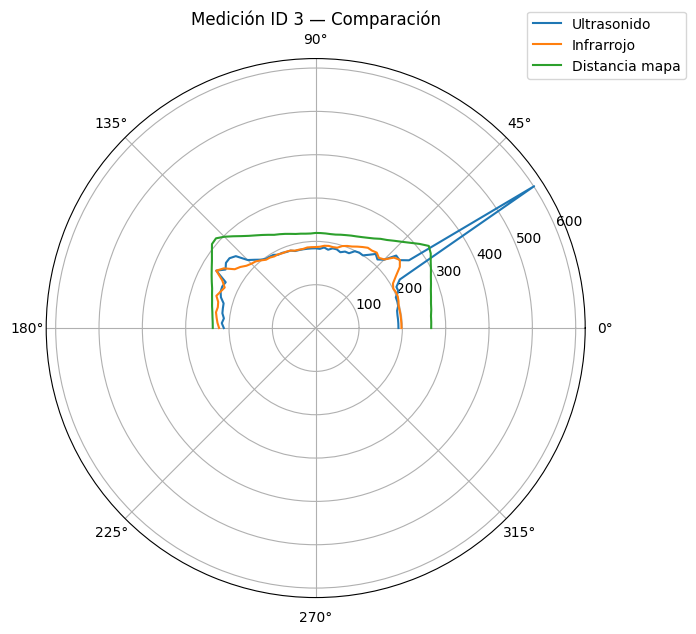

In [ ]:
#idx = 3
#dataset.plot_idx(df, idx, mode="overlay");